# Part 2 – NER with Feed-Forward Neural Network

Uses the **word embeddings** from Part 1 as fixed input features.  
Adjust `HIDDEN_DIM` (and optionally `LR`, `DROPOUT`) to tune the model.

## 0. Install dependencies

!pip install datasets scikit-learn torch -q

## 1. Paths & Hyperparameters

**`HIDDEN_DIM`** is the main hyperparameter – change it to experiment.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from data import load_data, NER_LABELS
from model import FeedForwardNER, train_epoch, evaluate

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\mabot\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 2. Load Data

In [ ]:
from data import load_data, NER_LABELS
from model import make_loaders

(X_train, y_train), (X_val, y_val), (X_test, y_test), word2idx, embeddings = \
    load_data(VOCAB_PATH, EMBEDDINGS_PATH)

print(f"Train : {len(y_train):>7,} tokens")
print(f"Val   : {len(y_val):>7,} tokens")
print(f"Test  : {len(y_test):>7,} tokens")
print(f"Embed dim : {X_train.shape[1]}")
print(f"Classes   : {NER_LABELS}")

train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val, BATCH_SIZE)

# Keep test as tensors for evaluate()
import torch
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)
X_val_t  = torch.tensor(X_val,  dtype=torch.float32)
y_val_t  = torch.tensor(y_val,  dtype=torch.long)

## 3. Build Model

In [11]:
VOCAB_PATH      = "vocab.pkl"
EMBEDDINGS_PATH = "word_embeddings.npy"
WINDOW          = 2  # context window: uses [i-2, i-1, i, i+1, i+2]

(X_train, y_train), (X_val, y_val), (X_test, y_test), word2idx, embeddings = \
    load_data(VOCAB_PATH, EMBEDDINGS_PATH)

# Convert to tensors
to_tensor = lambda X, y: (torch.tensor(X, dtype=torch.float32),
                        torch.tensor(y, dtype=torch.long))

X_train_t, y_train_t = to_tensor(X_train, y_train)
X_val_t,   y_val_t   = to_tensor(X_val,   y_val)
X_test_t,  y_test_t  = to_tensor(X_test,  y_test)

embed_dim = X_train_t.shape[1]
input_dim = X_train_t.shape[1]   # embed_dim * (2*window+1)

print(f"Train : {len(y_train_t):>7,} tokens")
print(f"Val   : {len(y_val_t):>7,} tokens")
print(f"Test  : {len(y_test_t):>7,} tokens")
print(f"Embed dim : {embed_dim}")
print(f"Classes   : {NER_LABELS}")

Train : 203,621 tokens
Val   :  51,362 tokens
Test  :  46,435 tokens
Embed dim : 100
Classes   : ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


## 4. Hyperparameter grid

In [16]:
EPOCHS     = 10
BATCH_SIZE = 256

search_space = {
    "hidden_dims": [[128], [256], [256, 128]],
    "lr":          [1e-3, 5e-4],
    "dropout":     [0.3],
}

from itertools import product

keys    = list(search_space.keys())
combos  = list(product(*search_space.values()))
configs = [dict(zip(keys, c)) for c in combos]

print(f"Context window : {WINDOW} (fixed, set above in Cell 3)")
print(f"Input dim      : {input_dim}")
print(f"Total configs  : {len(configs)}")
for i, cfg in enumerate(configs):
    print(f"  [{i+1}] {cfg}")

Context window : 2 (fixed, set above in Cell 3)
Input dim      : 100
Total configs  : 6
  [1] {'hidden_dims': [128], 'lr': 0.001, 'dropout': 0.3}
  [2] {'hidden_dims': [128], 'lr': 0.0005, 'dropout': 0.3}
  [3] {'hidden_dims': [256], 'lr': 0.001, 'dropout': 0.3}
  [4] {'hidden_dims': [256], 'lr': 0.0005, 'dropout': 0.3}
  [5] {'hidden_dims': [256, 128], 'lr': 0.001, 'dropout': 0.3}
  [6] {'hidden_dims': [256, 128], 'lr': 0.0005, 'dropout': 0.3}


## 5. Hyperparameter search loop

In [17]:
results = []

for i, cfg in enumerate(configs):
    torch.manual_seed(47)

    model     = FeedForwardNER(input_dim, cfg["hidden_dims"],   
                            dropout=cfg["dropout"]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    criterion = nn.CrossEntropyLoss()
    loader    = DataLoader(TensorDataset(X_train_t, y_train_t),
                        batch_size=BATCH_SIZE, shuffle=True)

    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch(model, loader, optimizer, criterion, device)

    metrics = evaluate(model, X_val_t, y_val_t, device)

    results.append({**cfg, "val_f1": metrics["f1"],
                    "val_acc": metrics["accuracy"], "model": model})

    print(f"[{i+1}/{len(configs)}] hidden={cfg['hidden_dims']}  "
        f"lr={cfg['lr']}  dropout={cfg['dropout']}  "
        f"→ Val Acc={metrics['accuracy']:.4f}  Val F1={metrics['f1']:.4f}")

[1/6] hidden=[128]  lr=0.001  dropout=0.3  → Val Acc=0.8666  Val F1=0.3849
[2/6] hidden=[128]  lr=0.0005  dropout=0.3  → Val Acc=0.8576  Val F1=0.3159
[3/6] hidden=[256]  lr=0.001  dropout=0.3  → Val Acc=0.8768  Val F1=0.4395
[4/6] hidden=[256]  lr=0.0005  dropout=0.3  → Val Acc=0.8661  Val F1=0.3833
[5/6] hidden=[256, 128]  lr=0.001  dropout=0.3  → Val Acc=0.8948  Val F1=0.5131
[6/6] hidden=[256, 128]  lr=0.0005  dropout=0.3  → Val Acc=0.8830  Val F1=0.4529


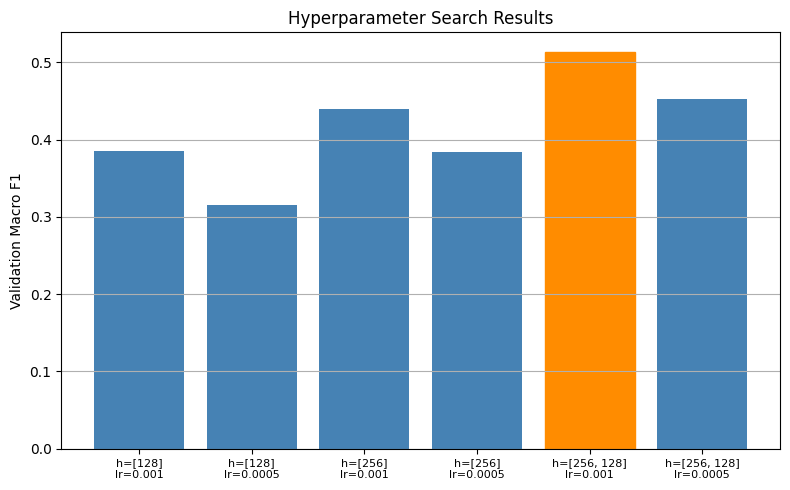

In [18]:
labels = [f"h={r['hidden_dims']}\nlr={r['lr']}" for r in results]
f1s    = [r["val_f1"] for r in results]

plt.figure(figsize=(max(8, len(results)*1.2), 5))
bars = plt.bar(labels, f1s, color='steelblue')
bars[f1s.index(max(f1s))].set_color('darkorange')   # highlight best
plt.ylabel("Validation Macro F1")
plt.title("Hyperparameter Search Results")
plt.xticks(fontsize=8)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("hyperparam_search.png", dpi=120)
plt.show()

## 6. Pick best config

In [19]:
best = max(results, key=lambda r: r["val_f1"])

print("=" * 50)
print("BEST CONFIG")
print("=" * 50)
print(f"  hidden_dims : {best['hidden_dims']}")
print(f"  lr          : {best['lr']}")
print(f"  dropout     : {best['dropout']}")
print(f"  Val F1      : {best['val_f1']:.4f}")
print(f"  Val Acc     : {best['val_acc']:.4f}")

BEST CONFIG
  hidden_dims : [256, 128]
  lr          : 0.001
  dropout     : 0.3
  Val F1      : 0.5131
  Val Acc     : 0.8948


## 7.  Retrain best config for all epochs and plot curves


Epoch 01/10  Loss=0.6624  Val Acc=0.8541  Val F1=0.2100
Epoch 02/10  Loss=0.5395  Val Acc=0.8627  Val F1=0.3115
Epoch 03/10  Loss=0.4991  Val Acc=0.8704  Val F1=0.3997
Epoch 04/10  Loss=0.4713  Val Acc=0.8771  Val F1=0.4338
Epoch 05/10  Loss=0.4501  Val Acc=0.8811  Val F1=0.4496
Epoch 06/10  Loss=0.4341  Val Acc=0.8846  Val F1=0.4687
Epoch 07/10  Loss=0.4204  Val Acc=0.8872  Val F1=0.4739
Epoch 08/10  Loss=0.4082  Val Acc=0.8904  Val F1=0.5009
Epoch 09/10  Loss=0.3974  Val Acc=0.8907  Val F1=0.4920
Epoch 10/10  Loss=0.3880  Val Acc=0.8933  Val F1=0.5010


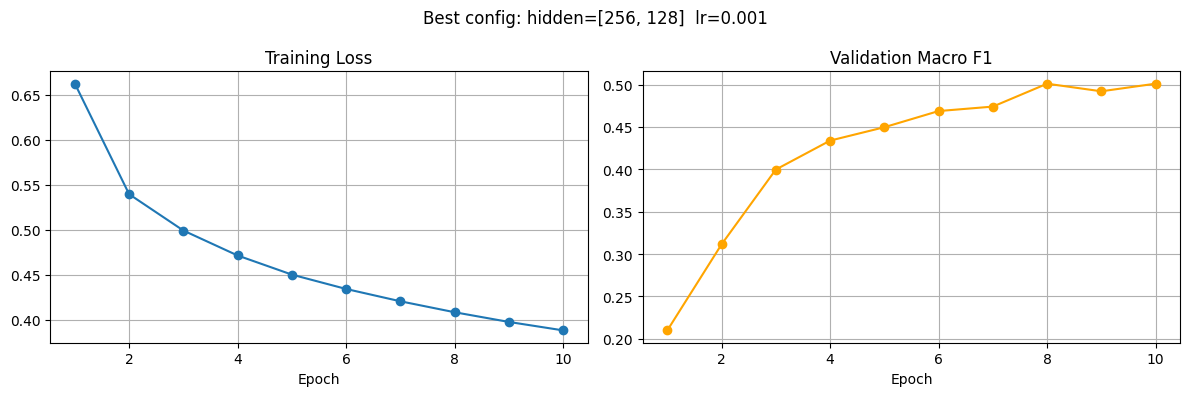

In [20]:
torch.manual_seed(42)

best_model = FeedForwardNER(input_dim, best["hidden_dims"],
                            dropout=best["dropout"]).to(device)
optimizer  = torch.optim.Adam(best_model.parameters(), lr=best["lr"])
criterion  = nn.CrossEntropyLoss()
loader     = DataLoader(TensorDataset(X_train_t, y_train_t),
                        batch_size=BATCH_SIZE, shuffle=True)

train_losses, val_f1s = [], []

for epoch in range(1, EPOCHS + 1):
    loss    = train_epoch(best_model, loader, optimizer, criterion, device)
    metrics = evaluate(best_model, X_val_t, y_val_t, device)
    train_losses.append(loss)
    val_f1s.append(metrics["f1"])
    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss={loss:.4f}  "
        f"Val Acc={metrics['accuracy']:.4f}  Val F1={metrics['f1']:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS+1), train_losses, marker='o')
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(True)

axes[1].plot(range(1, EPOCHS+1), val_f1s, marker='o', color='orange')
axes[1].set_title("Validation Macro F1"); axes[1].set_xlabel("Epoch"); axes[1].grid(True)

plt.suptitle(f"Best config: hidden={best['hidden_dims']}  lr={best['lr']}", fontsize=12)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()

## 8.   Final test evaluation


In [21]:
test_metrics = evaluate(best_model, X_test_t, y_test_t, device)

print("=" * 50)
print("TEST RESULTS  (best config)")
print("=" * 50)
print(f"Accuracy  : {test_metrics['accuracy']:.4f}")
print(f"Precision : {test_metrics['precision']:.4f}  (macro)")
print(f"Recall    : {test_metrics['recall']:.4f}  (macro)")
print(f"F1        : {test_metrics['f1']:.4f}  (macro)")
print()
print(test_metrics["report"])

TEST RESULTS  (best config)
Accuracy  : 0.8789
Precision : 0.6777  (macro)
Recall    : 0.4086  (macro)
F1        : 0.4770  (macro)

              precision    recall  f1-score   support

           0       0.90      0.99      0.94     38323
           1       0.53      0.29      0.38      1617
           2       0.43      0.01      0.01      1156
           3       0.61      0.41      0.49      1661
           4       0.67      0.14      0.23       835
           5       0.79      0.66      0.72      1668
           6       0.70      0.35      0.46       257
           7       0.77      0.42      0.54       702
           8       0.70      0.42      0.52       216

    accuracy                           0.88     46435
   macro avg       0.68      0.41      0.48     46435
weighted avg       0.85      0.88      0.85     46435



## 9. Conclusion

The model achieves **88% accuracy**, but this is misleading — the dataset is heavily imbalanced, with ~82% of tokens being the **O** (non-entity) class, which alone scores F1 = 0.94 and pulls the overall accuracy up.

Entity classes tell a different story. **I-PER** (F1 = 0.01) and **I-ORG** (F1 = 0.23) are particularly weak because the model processes each token independently — it has no memory of the previous tag. So even if it correctly identifies the start of an entity (B-), it often fails to continue it (I-), breaking multi-word entities like *"New York Times"* into fragments.

This is the core limitation of a feed-forward approach for sequence labeling: **without a sequence model (e.g. RNN or CRF), there is no mechanism to enforce that an I- tag must follow a B- tag**, leading to inconsistent and incomplete entity predictions.